
Fusion: (3500, 512)

Fold 1
Epoch 1/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.8018 - loss: 0.4304 - val_accuracy: 0.9286 - val_loss: 0.5665
Epoch 2/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9200 - loss: 0.2098 - val_accuracy: 0.9586 - val_loss: 0.3910
Epoch 3/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.9496 - loss: 0.1503 - val_accuracy: 0.9743 - val_loss: 0.1969
Epoch 4/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9589 - loss: 0.1179 - val_accuracy: 0.9843 - val_loss: 0.0968
Epoch 5/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9643 - loss: 0.0971 - val_accuracy: 0.9843 - val_loss: 0.0590
Epoch 6/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9689 - loss: 0.0862 - val_accuracy: 0.9843 - val_loss: 0.0625
Epoch 7/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9782 - loss: 0.0672 - val_accuracy: 0.9886 - val_loss: 0.0533
Epoch 8/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9814 - l

Accuracy: 99.71428571428571

Mean Accuracy: 99.22857142857143

STD: 0.005237229365663798
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       320
           1       1.00      1.00      1.00       380

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700

[[319   1]
 [  1 379]]


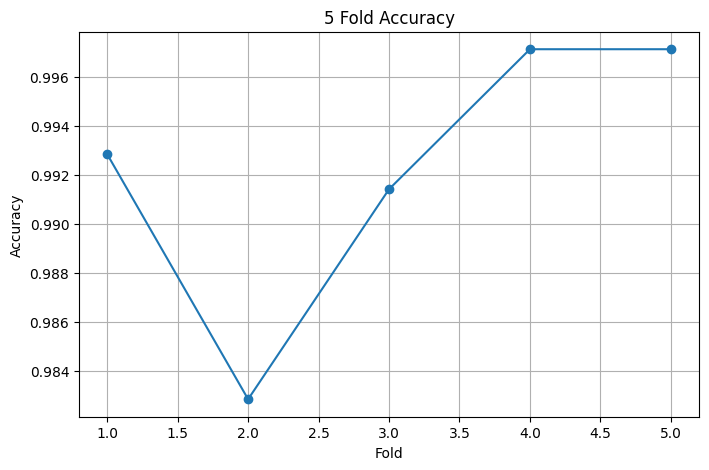

In [1]:
import numpy as np
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import (
LabelEncoder,
StandardScaler
)

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
confusion_matrix,
classification_report
)

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import *


# ====================================
# LOAD
# ====================================

ecg=np.load(
"ecg_features2.npy"
)

ppg=np.load(
"ppg_features2.npy"
)

y=np.load(
"labels2.npy"
)


enc=LabelEncoder()

y=enc.fit_transform(
y
)

joblib.dump(

enc,

"multimodal_label_encoder.pkl"

)


classes=len(
np.unique(y)
)


# ====================================
# FUSION
# ====================================

X=np.concatenate(

[
ecg,
ppg
],

axis=1

)

print(
"\nFusion:",
X.shape
)


# ====================================
# MODEL
# ====================================

def build(input_dim):

    inp=Input(
    (
    input_dim,
    )
    )

    x=BatchNormalization()(inp)

    x=Dense(
    512,
    activation="swish"
    )(x)

    x=Dropout(
    0.15
    )(x)

    # RESIDUAL

    skip=x

    x=Dense(
    512,
    activation="swish"
    )(x)

    x=BatchNormalization()(x)

    x=Dropout(
    0.15
    )(x)

    x=Dense(
    512
    )(x)

    x=Add()(

    [
    x,
    skip
    ]

    )

    x=Activation(
    "swish"
    )(x)


    # GATE

    gate=Dense(
    512,
    activation="sigmoid"
    )(x)

    x=Multiply()(

    [
    x,
    gate
    ]

    )


    x=Dense(
    256,
    activation="swish"
    )(x)

    x=BatchNormalization()(x)

    x=Dropout(
    0.20
    )(x)

    x=Dense(
    128,
    activation="swish"
    )(x)

    x=Dropout(
    0.20
    )(x)

    out=Dense(
    classes,
    activation="softmax"
    )(x)

    model=Model(
    inp,
    out
    )

    model.compile(

    optimizer=tf.keras.optimizers.AdamW(

    learning_rate=1e-4,

    weight_decay=1e-5

    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

    )

    return model


# ====================================
# KFOLD
# ====================================

kf=StratifiedKFold(

n_splits=5,

shuffle=True,

random_state=42

)

scores=[]


for fold,(tr,val) in enumerate(

kf.split(
X,
y
)

):

    print(
    f"\nFold {fold+1}"
    )

    scaler=StandardScaler()

    X_train=scaler.fit_transform(
    X[tr]
    )

    X_val=scaler.transform(
    X[val]
    )

    joblib.dump(

    scaler,

    "multimodal_scaler.pkl"

    )

    model=build(
    X.shape[1]
    )

    cb=[

    EarlyStopping(

    monitor="val_loss",

    patience=20,

    restore_best_weights=True

    )

    ]

    model.fit(

    X_train,

    y[tr],

    validation_data=(

    X_val,

    y[val]

    ),

    epochs=150,

    batch_size=32,

    callbacks=cb,

    verbose=1

    )

    prob=model.predict(
    X_val
    )

    pred=np.argmax(
    prob,
    axis=1
    )

    acc=accuracy_score(
    y[val],
    pred
    )

    scores.append(
    acc
    )

    print(
    "Accuracy:",
    acc*100
    )


# ====================================
# SAVE
# ====================================

model.save(

"multimodal_final_model_2.h5"

)


# ====================================
# METRICS
# ====================================

print(
"\nMean Accuracy:",
np.mean(
scores
)*100
)

print(
"\nSTD:",
np.std(
scores
)
)

print(

classification_report(

y[val],

pred

)

)

cm=confusion_matrix(

y[val],

pred

)

print(
cm
)


plt.figure(
figsize=(8,5)
)

plt.plot(

range(

1,

6

),

scores,

marker="o"

)

plt.title(

"5 Fold Accuracy"

)

plt.xlabel(

"Fold"

)

plt.ylabel(

"Accuracy"

)

plt.grid()

plt.show()